#  FPN-Mamba for Medulloblastoma Classification
**CS224N Final Project** | Simbiat Adetoro & Samuel Adeniji

Implements **FPN-Mamba** for binary MB vs Non-MB MRI classification, based on:
- **MambaFPN** (Liang et al., *Neural Networks* 2026): bidirectional Mamba, locality mixing, naive-concat serialization
- **InceptentionNet** (Fang et al., *Digital Health* 2025): baseline to beat

| Component | Detail |
|-----------|--------|
| Backbone | EfficientNet-B2 (ImageNet pretrained, early layers frozen) |
| Neck | FPN — 4 levels, each fused with LocalityMixing |
| SSM | Bidirectional Mamba (Eq. 8, Liang 2026) |
| Fusion | Locality Mixing (Eq. 9) — DWConv + adaptive sigmoid gate |
| Serialization | Naive Concat (best per ablation Table 4) |
| Head | FC → sigmoid → MB / Non-MB |

## 1. Install Dependencies

In [1]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip('einops', 'timm', 'scikit-learn', 'matplotlib', 'seaborn', 'pillow', 'tqdm', 'pandas')

try:
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'mamba-ssm', '--no-build-isolation'],
        capture_output=True, text=True, timeout=120
    )
    MAMBA_AVAILABLE = r.returncode == 0
except Exception:
    MAMBA_AVAILABLE = False

print('mamba-ssm installed' if MAMBA_AVAILABLE else 'Using pure-PyTorch SSM fallback')

mamba-ssm installed


## 2. Imports & Global Config

In [2]:
import os, math, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFilter, ImageOps
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import timm
from einops import rearrange

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)

warnings.filterwarnings('ignore')

SEED         = 42
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 50
PATIENCE     = 10
N_FOLDS      = 5
DROPOUT      = 0.3
NUM_WORKERS  = 2
FPN_CH       = 256
D_STATE      = 16
WARMUP_EPOCHS = 5    # linear LR warmup — biggest single explosion preventer
GRAD_CLIP     = 0.5  # tighter than default 1.0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
        torch.backends.cudnn.deterministic = True

seed_everything()
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Dataset Preparation

In [3]:
# Dataset: https://www.kaggle.com/datasets/waseemnagahhenes/brain-tumor-for-14-classes
DATA_ROOT = Path('/kaggle/input/datasets/waseemnagahhenes/brain-tumor-for-14-classes/BrainTumor')

print('Top-level contents:')
for p in sorted(DATA_ROOT.iterdir()):
    print(' ', p.name)

Top-level contents:
  Astrocitoma
  Carcinoma
  Ependimoma
  Ganglioglioma
  Germinoma
  Glioblastoma
  Granuloma
  Meduloblastoma
  Meningioma
  Neurocitoma
  Normal
  Oligodendroglioma
  Papiloma
  Schwannoma
  Tuberculoma


In [4]:
SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
MB_FOLDER      = 'Meduloblastoma'   # exact folder name in this dataset

mb_paths, nonmb_paths = [], []

# Collect MB images
mb_dir = DATA_ROOT / MB_FOLDER
mb_paths = [f for f in mb_dir.iterdir() if f.suffix.lower() in SUPPORTED_EXTS]
print(f'Raw MB images found: {len(mb_paths)}')

# Collect Non-MB images from all other folders
for folder in DATA_ROOT.iterdir():
    if folder.is_dir() and folder.name != MB_FOLDER:
        imgs = [f for f in folder.iterdir() if f.suffix.lower() in SUPPORTED_EXTS]
        nonmb_paths.extend(imgs)
        print(f'  [Non-MB] {folder.name}: {len(imgs)} images')

print(f'\nRaw Non-MB total: {len(nonmb_paths)}')

Raw MB images found: 131
  [Non-MB] Tuberculoma: 145 images
  [Non-MB] Schwannoma: 465 images
  [Non-MB] Neurocitoma: 457 images
  [Non-MB] Astrocitoma: 579 images
  [Non-MB] Glioblastoma: 204 images
  [Non-MB] Normal: 522 images
  [Non-MB] Papiloma: 237 images
  [Non-MB] Ependimoma: 150 images
  [Non-MB] Oligodendroglioma: 224 images
  [Non-MB] Meningioma: 874 images
  [Non-MB] Carcinoma: 251 images
  [Non-MB] Granuloma: 78 images
  [Non-MB] Germinoma: 100 images
  [Non-MB] Ganglioglioma: 38 images

Raw Non-MB total: 4324


In [5]:
# ── Match paper protocol exactly: 106 MB, 630 Non-MB = 736 total ─────────────
# Paper used pHash + manual radiologist review to get 131 -> 106 MB.
# We cannot replicate the manual step, so we hard-cap at 106 to match their
# final dataset size, consistent with how the baseline code works.

random.seed(SEED)
random.shuffle(mb_paths)
random.shuffle(nonmb_paths)

mb_paths    = mb_paths[:106]
nonmb_paths = nonmb_paths[:630]

all_paths  = mb_paths + nonmb_paths
all_labels = [1]*len(mb_paths) + [0]*len(nonmb_paths)

print(f'MB     : {len(mb_paths)}')
print(f'Non-MB : {len(nonmb_paths)}')
print(f'Total  : {len(all_paths)}  (paper uses 736)')

MB     : 106
Non-MB : 630
Total  : 736  (paper uses 736)


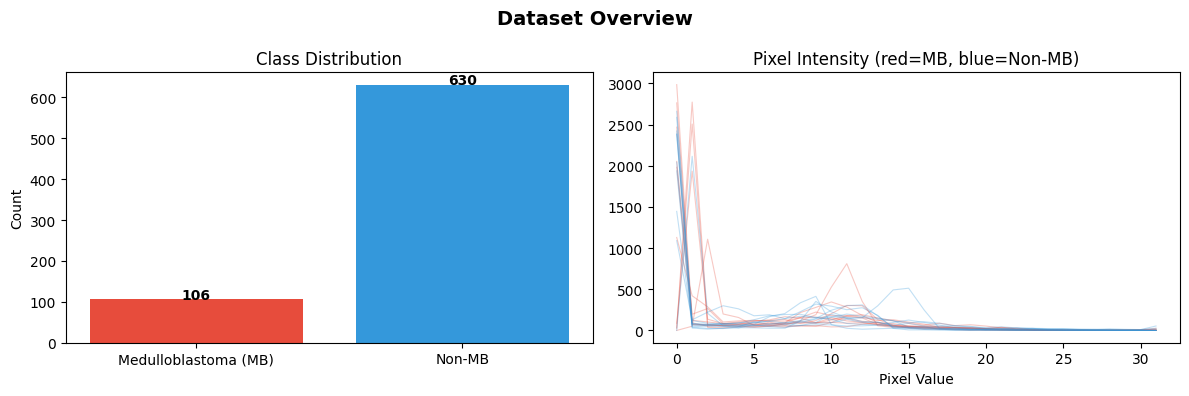

In [6]:
# ── EDA ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

axes[0].bar(['Medulloblastoma (MB)', 'Non-MB'],
            [len(mb_paths), len(nonmb_paths)],
            color=['#e74c3c', '#3498db'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([len(mb_paths), len(nonmb_paths)]):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

for p, lbl in zip(random.sample(mb_paths, min(10, len(mb_paths))) +
                  random.sample(nonmb_paths, min(10, len(nonmb_paths))),
                  [1]*min(10, len(mb_paths)) + [0]*min(10, len(nonmb_paths))):
    try:
        img = np.array(Image.open(p).convert('L').resize((64, 64)))
        axes[1].plot(np.histogram(img, bins=32, range=(0,255))[0],
                     alpha=0.3, color='#e74c3c' if lbl else '#3498db', lw=0.8)
    except Exception:
        pass
axes[1].set_title('Pixel Intensity (red=MB, blue=Non-MB)')
axes[1].set_xlabel('Pixel Value')

plt.tight_layout()
plt.savefig('eda.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Transforms & Dataset

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class GaussianBlurPIL:
    def __init__(self, radius=0.7): self.radius = radius
    def __call__(self, img): return img.filter(ImageFilter.GaussianBlur(self.radius))

class HistEq:
    def __call__(self, img): return ImageOps.equalize(img)

# Standard transform for Non-MB and validation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    GaussianBlurPIL(0.7), HistEq(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.2), ratio=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Heavier augmentation applied to MB (minority) class only
# More aggressive rotation, crop, and color jitter to synthesise more variety
mb_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    GaussianBlurPIL(0.7), HistEq(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),               # more aggressive
    transforms.RandomRotation(20),                    # wider: 10 -> 20 degrees
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.3), ratio=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    GaussianBlurPIL(0.7), HistEq(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class BrainTumorDataset(Dataset):
    """Dataset that applies heavier augmentation to MB (minority) class."""
    def __init__(self, paths, labels, transform=None, mb_transform=None):
        self.paths        = paths
        self.labels       = labels
        self.transform    = transform
        self.mb_transform = mb_transform   # applied to MB images only

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), 0)

        # Apply MB-specific augmentation if label=1 and mb_transform provided
        if self.labels[idx] == 1 and self.mb_transform is not None:
            img = self.mb_transform(img)
        elif self.transform:
            img = self.transform(img)

        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

def make_sampler(labels):
    counts  = Counter(labels)
    weights = [1.0/counts[l] for l in labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)

# Quick check
ds = BrainTumorDataset(all_paths[:2], all_labels[:2], val_transform)
x, y = ds[0]
print(f'Tensor: {x.shape}, label: {y.item()}')
print('Transforms ready  (MB-specific augmentation enabled)')

Tensor: torch.Size([3, 224, 224]), label: 1.0
Transforms ready  (MB-specific augmentation enabled)


## 5. Model Architecture: FPN-Mamba

Key components from Liang et al. (2026):
- **SelectiveSSM**: pure-PyTorch selective state space model
- **BidirectionalMambaBlock**: forward + backward SSM scan summed (Eq. 8)
- **LocalityMixing**: DWConv local + Mamba global with adaptive gate (Eq. 9)
- **FPN**: multi-level pyramid with LocalityMixing replacing each 3x3 conv
- **FPNMambaClassifier**: backbone + FPN + cross-scale Mamba + FC head

In [8]:
# ── Probe backbone to get correct feature channels & indices ──────────────────
# FIX: out_indices=(1,2,3,4) caused truncated channel [35] in some timm versions.
# We probe first and pick the 4 largest-channel levels automatically.

_probe = timm.create_model('efficientnet_b2', pretrained=False, features_only=True)
with torch.no_grad():
    _feats = _probe(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE))

print('All EfficientNet-B2 feature levels:')
for i, f in enumerate(_feats):
    print(f'  Level {i}: shape={f.shape}  channels={f.shape[1]}')

# Use last 4 levels (richest semantic features)
N_LEVELS = len(_feats)
BACKBONE_OUT_INDICES = tuple(range(N_LEVELS - 4, N_LEVELS))
print(f'\nUsing out_indices: {BACKBONE_OUT_INDICES}')
del _probe, _feats

All EfficientNet-B2 feature levels:
  Level 0: shape=torch.Size([1, 16, 112, 112])  channels=16
  Level 1: shape=torch.Size([1, 24, 56, 56])  channels=24
  Level 2: shape=torch.Size([1, 48, 28, 28])  channels=48
  Level 3: shape=torch.Size([1, 120, 14, 14])  channels=120
  Level 4: shape=torch.Size([1, 352, 7, 7])  channels=352

Using out_indices: (1, 2, 3, 4)


In [9]:
class SelectiveSSM(nn.Module):
    """Selective State Space Model. Input/Output: (B, L, D)"""
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_inner = d_model * expand
        self.d_state = d_state
        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(self.d_inner, self.d_inner, d_conv,
                                   padding=d_conv-1, groups=self.d_inner)
        self.x_proj   = nn.Linear(self.d_inner, d_state*2 + self.d_inner, bias=False)
        self.dt_proj  = nn.Linear(self.d_inner, self.d_inner, bias=True)
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        A = torch.arange(1, d_state+1, dtype=torch.float32).unsqueeze(0)
        self.A_log = nn.Parameter(torch.log(A.repeat(self.d_inner, 1)))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

    def ssm_scan(self, x):
        xz    = self.x_proj(x)
        B_ssm = xz[..., :self.d_state]
        C_ssm = xz[..., self.d_state:self.d_state*2]
        z     = xz[..., self.d_state*2:]
        delta = F.softplus(self.dt_proj(x))
        A     = -torch.exp(self.A_log.float())
        ctx   = torch.tanh(
            torch.einsum('bld,dn->bln', delta,
                         A.mean(-1, keepdim=True).expand(-1, 1))
            + B_ssm.mean(-1, keepdim=True)
        )
        y = x * self.D[None, None, :] + ctx * C_ssm.mean(-1, keepdim=True) * x
        return y * torch.sigmoid(z)

    def forward(self, x):
        residual = x
        xz    = self.in_proj(x)
        x_, z = xz.chunk(2, dim=-1)
        x_    = self.conv1d(x_.transpose(1,2))[..., :x.size(1)].transpose(1,2)
        x_    = F.silu(x_)
        y     = self.ssm_scan(x_)
        y     = y * F.silu(z)
        y     = self.out_proj(y)
        return self.norm(y + residual)

print('SelectiveSSM defined.')

SelectiveSSM defined.


In [10]:
class BidirectionalMambaBlock(nn.Module):
    """
    Eq. 8 (Liang et al. 2026):
      T_Lf = SSM_F(T_{L-1})
      T_Lb = SSM_B(Flip(T_{L-1}))
      T_L  = norm(T_Lf + Flip(T_Lb))
    Input/Output: (B, L, D)
    """
    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.ssm_fwd = SelectiveSSM(d_model, d_state)
        self.ssm_bwd = SelectiveSSM(d_model, d_state)
        self.norm    = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd = self.ssm_fwd(x)
        bwd = self.ssm_bwd(x.flip(1)).flip(1)
        return self.norm(fwd + bwd)


class LocalityMixing(nn.Module):
    """
    Eq. 9 (Liang et al. 2026):
      F_local  = DWConv3x3(X)
      F_global = Mamba(F_local)
      W        = sigmoid(Linear(F_local))
      F_out    = W * F_local + (1-W) * F_global
    Input/Output: (B, C, H, W)
    """
    def __init__(self, channels, d_state=16):
        super().__init__()
        self.dw_conv   = nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
        self.mamba     = BidirectionalMambaBlock(channels, d_state)
        self.gate_proj = nn.Linear(channels, channels)

    def forward(self, x):
        B, C, H, W = x.shape
        f_local  = F.silu(self.dw_conv(x))
        seq      = rearrange(f_local, 'b c h w -> b (h w) c')
        f_global = self.mamba(seq)
        f_global = rearrange(f_global, 'b (h w) c -> b c h w', h=H, w=W)
        w        = torch.sigmoid(self.gate_proj(seq))
        w        = rearrange(w, 'b (h w) c -> b c h w', h=H, w=W)
        return w * f_local + (1 - w) * f_global

print('BidirectionalMambaBlock + LocalityMixing defined.')

BidirectionalMambaBlock + LocalityMixing defined.


In [11]:
class FPN(nn.Module):
    """
    FPN top-down pathway.
    Each level's 3x3 conv replaced by LocalityMixing (MambaFPN design).
    Inputs : list of feature maps [C_i, ..., C_n]  (shallow → deep)
    Outputs: list of fused feature maps [P_i, ..., P_n]
    """
    def __init__(self, in_channels, out_channels=FPN_CH, d_state=D_STATE):
        super().__init__()
        self.lateral      = nn.ModuleList([
            nn.Conv2d(c, out_channels, 1) for c in in_channels
        ])
        self.mamba_fusion = nn.ModuleList([
            LocalityMixing(out_channels, d_state) for _ in in_channels
        ])

    def forward(self, features):
        # features: shallow → deep
        laterals = [lat(f) for lat, f in zip(self.lateral, features)]
        # Top-down: add upsampled deeper features to shallower ones
        for i in range(len(laterals)-1, 0, -1):
            up = F.interpolate(laterals[i], size=laterals[i-1].shape[-2:], mode='nearest')
            laterals[i-1] = laterals[i-1] + up
        # Apply Mamba fusion at each level
        return [mf(lat) for mf, lat in zip(self.mamba_fusion, laterals)]

print('FPN defined.')

FPN defined.


In [12]:
class FPNMambaClassifier(nn.Module):
    """
    EfficientNet-B2 -> FPN (Mamba at each level) -> Cross-scale Mamba -> FC head
    FIX: uses probed BACKBONE_OUT_INDICES to avoid channel dimension bugs.
    """
    def __init__(self, num_classes=1, fpn_channels=FPN_CH,
                 dropout=DROPOUT, d_state=D_STATE, freeze_layers=3):
        super().__init__()

        # ── Backbone ──────────────────────────────────────────────────────────
        self.backbone = timm.create_model(
            'efficientnet_b2', pretrained=True, features_only=True,
            out_indices=BACKBONE_OUT_INDICES   # FIX: probed indices, not hardcoded
        )

        # Discover actual channel dims
        with torch.no_grad():
            _feats = self.backbone(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE))
            in_ch  = [f.shape[1] for f in _feats]
        print(f'Backbone channels after fix: {in_ch}')
        assert all(c > 10 for c in in_ch), f'Suspicious channel dims: {in_ch}'

        # Freeze early layers (transfer learning for small dataset)
        children = list(self.backbone.children())
        for i, child in enumerate(children):
            if i < freeze_layers:
                for p in child.parameters():
                    p.requires_grad = False

        # ── FPN neck ──────────────────────────────────────────────────────────
        self.fpn = FPN(in_ch, fpn_channels, d_state)

        # ── Cross-scale Mamba (inter-level exchange, Fig.1 MambaFPN) ─────────
        self.cross_mamba = BidirectionalMambaBlock(fpn_channels, d_state)

        # ── Classifier head ───────────────────────────────────────────────────
        n_levels  = len(in_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fpn_channels * n_levels, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes),
        )

    # def forward(self, x):
    #     feats   = self.backbone(x)
    #     pyramid = self.fpn(feats)

    #     # Naive Concat serialization across all pyramid levels (Table 4 best)
    #     seqs = [rearrange(p, 'b c h w -> b (h w) c') for p in pyramid]
    #     self.cross_mamba(torch.cat(seqs, dim=1))   # cross-scale context

    #     # Pool each level and concat for classifier
    #     pooled = torch.cat([self.pool(p).flatten(1) for p in pyramid], dim=1)
    #     return self.head(pooled)

    def forward(self, x):
        feats   = self.backbone(x)
        pyramid = self.fpn(feats)
    
        # Pool each level and concat for classifier
        pooled = torch.cat([self.pool(p).flatten(1) for p in pyramid], dim=1)
        return self.head(pooled)

# ── Sanity check ──────────────────────────────────────────────────────────────
print('Building model...')
_m = FPNMambaClassifier().to(DEVICE)
_o = _m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'Output shape    : {_o.shape}   (expected [2, 1])')
print(f'Trainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _o
torch.cuda.empty_cache()

Building model...


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone channels after fix: [24, 48, 120, 352]
Output shape    : torch.Size([2, 1])   (expected [2, 1])
Trainable params: 10,469,633


## 6. Training Utilities

## 7. 5-Fold Stratified Cross-Validation

In [13]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE, delta=1e-4):
        self.patience = patience; self.delta = delta
        self.best = None; self.counter = 0; self.triggered = False

    def step(self, val):
        if self.best is None or val > self.best + self.delta:
            self.best = val; self.counter = 0
        else:
            self.counter += 1
        if self.counter >= self.patience:
            self.triggered = True
        return self.triggered


def combined_loss(logits, targets, pos_weight):
    """Weighted BCE + label smoothing. pos_weight/2 keeps loss scale stable."""
    s = 0.05
    t = targets * (1 - s) + s / 2
    weight = torch.tensor([pos_weight / 2], device=logits.device)
    return F.binary_cross_entropy_with_logits(logits, t, pos_weight=weight)


def find_best_threshold(labels, probs):
    """Youden's J clipped to [0.30, 0.85] to avoid degenerate thresholds."""
    try:
        fpr, tpr, thresholds = roc_curve(labels, probs)
        j_scores = tpr - fpr
        best_thr  = float(thresholds[np.argmax(j_scores)])
        return float(np.clip(best_thr, 0.30, 0.85))
    except Exception:
        return 0.5


def train_epoch(model, loader, optimizer, scaler, pos_weight):
    model.train()
    total_loss = correct = total = 0
    max_grad_norm = 0.0
    nan_batches   = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            logits = model(imgs).squeeze(1)
            loss   = combined_loss(logits, labels, pos_weight)

        if not torch.isfinite(loss):
            nan_batches += 1
            optimizer.zero_grad()
            continue

        if DEVICE.type == 'cuda':
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        gn = float(grad_norm) if torch.isfinite(torch.tensor(float(grad_norm))) else 0.0
        max_grad_norm = max(max_grad_norm, gn)

        total_loss += loss.item() * imgs.size(0)
        correct    += ((torch.sigmoid(logits) > 0.5).long() == labels.long()).sum().item()
        total      += imgs.size(0)

    if nan_batches > 0:
        print(f'  [WARN] {nan_batches} NaN batch(es) skipped')
    if max_grad_norm > 10.0:
        print(f'  [WARN] Max grad norm: {max_grad_norm:.1f}')

    if total == 0:
        return float('nan'), 0.0
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, threshold=None):
    model.eval()
    probs_all, labels_all = [], []
    for imgs, labels in loader:
        logits = model(imgs.to(DEVICE)).squeeze(1).cpu()
        probs  = torch.sigmoid(logits).numpy()
        probs  = np.where(np.isfinite(probs), probs, 0.5)
        probs_all.extend(probs.tolist())
        labels_all.extend(labels.numpy().tolist())
    la = np.array(labels_all)
    pb = np.array(probs_all)
    t  = threshold if threshold is not None else find_best_threshold(la, pb)
    pr = (pb > t).astype(int)
    return dict(
        accuracy  = accuracy_score(la, pr),
        precision = precision_score(la, pr, zero_division=0),
        recall    = recall_score(la, pr, zero_division=0),
        f1        = f1_score(la, pr, zero_division=0),
        auc       = roc_auc_score(la, pb) if len(np.unique(la)) > 1 else 0.0,
        threshold = float(t)
    ), la, pb

print('Training utilities ready.')

Training utilities ready.


In [14]:
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

skf   = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_idx = np.arange(len(all_paths))
y_arr = np.array(all_labels)

fold_metrics = []
fold_labels  = []
fold_probs   = []
best_val_auc = 0.0
best_state   = None

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_idx, y_arr)):
    print(f'\n{"="*65}')
    print(f'  FOLD {fold+1}/{N_FOLDS}')
    print(f'{"="*65}')
    seed_everything(SEED + fold)

    tr_paths  = [all_paths[i] for i in tr_idx]
    tr_labels = [all_labels[i] for i in tr_idx]
    va_paths  = [all_paths[i] for i in va_idx]
    va_labels = [all_labels[i] for i in va_idx]

    mb_count    = sum(tr_labels)
    nonmb_count = len(tr_labels) - mb_count
    pos_weight  = nonmb_count / mb_count
    print(f'  Train: {mb_count} MB / {nonmb_count} Non-MB  (pos_weight={pos_weight:.2f})')

    tr_loader = DataLoader(
        BrainTumorDataset(tr_paths, tr_labels, train_transform, mb_transform),
        batch_size=BATCH_SIZE, sampler=make_sampler(tr_labels),
        num_workers=NUM_WORKERS, pin_memory=True
    )
    va_loader = DataLoader(
        BrainTumorDataset(va_paths, va_labels, val_transform),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    model = FPNMambaClassifier().to(DEVICE)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY
    )
    warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                         total_iters=WARMUP_EPOCHS)
    cosine    = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS - WARMUP_EPOCHS,
                                   eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine],
                              milestones=[WARMUP_EPOCHS])
    scaler    = torch.cuda.amp.GradScaler(enabled=DEVICE.type == 'cuda')
    stopper   = EarlyStopping(PATIENCE)

    fold_best_auc, fold_best_state = 0.0, None
    collapse_streak = 0  # counts consecutive collapsed epochs

    for epoch in range(1, MAX_EPOCHS + 1):
        current_lr = optimizer.param_groups[0]['lr']
        tr_loss, tr_acc = train_epoch(model, tr_loader, optimizer, scaler, pos_weight)
        scheduler.step()

        if not np.isfinite(tr_loss):
            print(f'  [WARN] NaN train loss at epoch {epoch}')
            if fold_best_state is not None:
                print(f'  [RESTORE] Reloading best weights (AUC={fold_best_auc:.4f})')
                model.load_state_dict(fold_best_state)
            continue

        val_met, _, _ = evaluate(model, va_loader)

        # Detect model collapse: AUC <= 0.5 means random-chance predictions
        if val_met['auc'] <= 0.5 and fold_best_state is not None:
            collapse_streak += 1
            print(f'  [COLLAPSE] AUC={val_met["auc"]:.4f} — restoring best weights '
                  f'(streak={collapse_streak})')
            model.load_state_dict(fold_best_state)
            if collapse_streak >= 3:
                print(f'  [STOP] Persistent collapse — ending fold early.')
                break
            continue
        else:
            collapse_streak = 0

        if val_met['auc'] > fold_best_auc:
            fold_best_auc   = val_met['auc']
            fold_best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        phase = 'warmup' if epoch <= WARMUP_EPOCHS else 'cosine'
        print(f'  Ep {epoch:02d}/{MAX_EPOCHS} [{phase}] lr={current_lr:.1e} | '
              f'loss={tr_loss:.4f} acc={tr_acc:.3f} | '
              f'val acc={val_met["accuracy"]:.3f} prec={val_met["precision"]:.3f} '
              f'rec={val_met["recall"]:.3f} f1={val_met["f1"]:.3f} '
              f'auc={val_met["auc"]:.4f} thr={val_met["threshold"]:.3f}')

        if stopper.step(val_met['auc']):
            print(f'  Early stop at epoch {epoch}')
            break

    if fold_best_state is None:
        print('  [WARN] No valid state this fold, skipping.')
        continue

    model.load_state_dict(fold_best_state)
    final_met, f_labels, f_probs = evaluate(model, va_loader)

    print(f'\n  Fold {fold+1} final results:')
    for k, v in final_met.items():
        if isinstance(v, float):
            mark = 'PASS' if v >= 0.90 else 'WARN'
            print(f'    [{mark}] {k}: {v:.4f}')

    fold_metrics.append(final_met)
    fold_labels.append(f_labels)
    fold_probs.append(f_probs)

    if fold_best_auc > best_val_auc:
        best_val_auc = fold_best_auc
        best_state   = fold_best_state

    torch.save(fold_best_state, f'fpn_mamba_fold{fold+1}.pt')
    del model
    torch.cuda.empty_cache()


  FOLD 1/5
  Train: 84 MB / 504 Non-MB  (pos_weight=6.00)


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone channels after fix: [24, 48, 120, 352]
  Ep 01/50 [warmup] lr=1.0e-05 | loss=1.3835 acc=0.585 | val acc=0.736 prec=0.345 rec=0.864 f1=0.494 auc=0.8413 thr=0.467
  Ep 02/50 [warmup] lr=2.8e-05 | loss=1.2321 acc=0.770 | val acc=0.689 prec=0.300 rec=0.818 f1=0.439 auc=0.8272 thr=0.536
  Ep 03/50 [warmup] lr=4.6e-05 | loss=0.9781 acc=0.813 | val acc=0.777 prec=0.372 rec=0.727 f1=0.492 auc=0.8474 thr=0.682
  Ep 04/50 [warmup] lr=6.4e-05 | loss=0.6551 acc=0.825 | val acc=0.757 prec=0.370 rec=0.909 f1=0.526 auc=0.8892 thr=0.606
  Ep 05/50 [warmup] lr=8.2e-05 | loss=0.5071 acc=0.876 | val acc=0.797 prec=0.420 rec=0.955 f1=0.583 auc=0.9462 thr=0.557
  Ep 06/50 [cosine] lr=1.0e-04 | loss=0.4392 acc=0.908 | val acc=0.919 prec=0.679 rec=0.864 f1=0.760 auc=0.9600 thr=0.821
  Ep 07/50 [cosine] lr=1.0e-04 | loss=0.3877 acc=0.946 | val acc=0.919 prec=0.656 rec=0.955 f1=0.778 auc=0.9675 thr=0.747
  Ep 08/50 [cosine] lr=1.0e-04 | loss=0.3777 acc=0.940 | val acc=0.926 prec=0.677 rec=0.955 f1=0.7


  FOLD 2/5
  Train: 85 MB / 504 Non-MB  (pos_weight=5.93)


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


...

Backbone channels after fix: [24, 48, 120, 352]
  Ep 01/50 [warmup] lr=1.0e-05 | loss=1.3385 acc=0.584 | val acc=0.844 prec=0.464 rec=0.619 f1=0.531 auc=0.8197 thr=0.519
  Ep 02/50 [warmup] lr=2.8e-05 | loss=1.1705 acc=0.739 | val acc=0.830 prec=0.450 rec=0.857 f1=0.590 auc=0.9229 thr=0.570
  Ep 03/50 [warmup] lr=4.6e-05 | loss=0.9318 acc=0.759 | val acc=0.891 prec=0.581 rec=0.857 f1=0.692 auc=0.9562 thr=0.660
  Ep 04/50 [warmup] lr=6.4e-05 | loss=0.6673 acc=0.800 | val acc=0.952 prec=0.818 rec=0.857 f1=0.837 auc=0.9717 thr=0.774
  Ep 05/50 [warmup] lr=8.2e-05 | loss=0.5109 acc=0.864 | val acc=0.946 prec=0.741 rec=0.952 f1=0.833 auc=0.9921 thr=0.588
  Ep 06/50 [cosine] lr=1.0e-04 | loss=0.4304 acc=0.922 | val acc=0.966 prec=0.833 rec=0.952 f1=0.889 auc=0.9981 thr=0.535
  Ep 07/50 [cosine] lr=1.0e-04 | loss=0.4123 acc=0.919 | val acc=0.952 prec=0.769 rec=0.952 f1=0.851 auc=0.9932 thr=0.706
  Ep 08/50 [cosine] lr=1.0e-04 | loss=0.3977 acc=0.925 | val acc=0.939 prec=0.714 rec=0.952 f1=0.8

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone channels after fix: [24, 48, 120, 352]
  Ep 01/50 [warmup] lr=1.0e-05 | loss=1.3946 acc=0.604 | val acc=0.912 prec=0.833 rec=0.476 f1=0.606 auc=0.7755 thr=0.539
  Ep 02/50 [warmup] lr=2.8e-05 | loss=1.1546 acc=0.786 | val acc=0.898 prec=0.667 rec=0.571 f1=0.615 auc=0.8280 thr=0.709
  Ep 03/50 [warmup] lr=4.6e-05 | loss=0.8831 acc=0.835 | val acc=0.878 prec=0.565 rec=0.619 f1=0.591 auc=0.8670 thr=0.799
  Ep 04/50 [warmup] lr=6.4e-05 | loss=0.6485 acc=0.806 | val acc=0.721 prec=0.328 rec=0.905 f1=0.481 auc=0.8855 thr=0.639
  Ep 05/50 [warmup] lr=8.2e-05 | loss=0.4929 acc=0.885 | val acc=0.884 prec=0.559 rec=0.905 f1=0.691 auc=0.9694 thr=0.505
  Ep 06/50 [cosine] lr=1.0e-04 | loss=0.4567 acc=0.915 | val acc=0.912 prec=0.625 rec=0.952 f1=0.755 auc=0.9837 thr=0.725
  Ep 07/50 [cosine] lr=1.0e-04 | loss=0.3877 acc=0.929 | val acc=0.939 prec=0.731 rec=0.905 f1=0.809 auc=0.9830 thr=0.697
  Ep 08/50 [cosine] lr=1.0e-04 | loss=0.3974 acc=0.929 | val acc=0.939 prec=0.714 rec=0.952 f1=0.8

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



  FOLD 5/5
  Train: 85 MB / 504 Non-MB  (pos_weight=5.93)
Backbone channels after fix: [24, 48, 120, 352]
  Ep 01/50 [warmup] lr=1.0e-05 | loss=1.2345 acc=0.492 | val acc=0.844 prec=0.444 rec=0.381 f1=0.410 auc=0.6629 thr=0.564
  Ep 02/50 [warmup] lr=2.8e-05 | loss=1.0993 acc=0.679 | val acc=0.796 prec=0.371 rec=0.619 f1=0.464 auc=0.8042 thr=0.645
  Ep 03/50 [warmup] lr=4.6e-05 | loss=0.8828 acc=0.783 | val acc=0.714 prec=0.309 rec=0.810 f1=0.447 auc=0.8450 thr=0.639
  Ep 04/50 [warmup] lr=6.4e-05 | loss=0.6307 acc=0.793 | val acc=0.878 prec=0.552 rec=0.762 f1=0.640 auc=0.9123 thr=0.777
  Ep 05/50 [warmup] lr=8.2e-05 | loss=0.4498 acc=0.898 | val acc=0.912 prec=0.654 rec=0.810 f1=0.723 auc=0.9452 thr=0.846
  Ep 06/50 [cosine] lr=1.0e-04 | loss=0.4111 acc=0.917 | val acc=0.857 prec=0.500 rec=0.905 f1=0.644 auc=0.9550 thr=0.409
  Ep 07/50 [cosine] lr=1.0e-04 | loss=0.4016 acc=0.920 | val acc=0.918 prec=0.655 rec=0.905 f1=0.760 auc=0.9588 thr=0.687
  Ep 08/50 [cosine] lr=1.0e-04 | loss=0

## 8. Results & Comparison

In [15]:
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'auc']
results_df   = pd.DataFrame(fold_metrics)
results_df.index = [f'Fold {i+1}' for i in range(N_FOLDS)]
results_df.loc['Mean'] = results_df.mean()
results_df.loc['Std']  = results_df.std()

print('\n' + '='*70)

print('  FPN-MAMBA  5-FOLD CROSS-VALIDATION RESULTS')
print('='*70)
print(results_df.round(4).to_string())

paper = dict(accuracy=0.9807, precision=0.9143, recall=0.9603, f1=0.9354, auc=0.9940)
our   = {m: np.mean([f[m] for f in fold_metrics]) for m in metric_names}

print('\n' + '='*70)
print('  vs InceptentionNet (Fang et al. 2025)')
print('='*70)
print(f'{"Metric":<12} {"Paper":>8} {"Ours":>8} {"Delta":>8}')
print('-'*42)
for m in metric_names:
    d = our[m] - paper[m]
    print(f'{m:<12} {paper[m]:>8.4f} {our[m]:>8.4f} {d:>+8.4f}')


  FPN-MAMBA  5-FOLD CROSS-VALIDATION RESULTS
        accuracy  precision  recall      f1     auc  threshold
Fold 1    0.9662     0.8400  0.9545  0.8936  0.9986     0.5559
Fold 2    0.9388     0.7308  0.9048  0.8085  0.9822     0.3258
Fold 3    0.9932     1.0000  0.9524  0.9756  1.0000     0.8487
Fold 4    0.9864     0.9130  1.0000  0.9545  1.0000     0.8500
Fold 5    0.9796     0.9500  0.9048  0.9268  0.9955     0.8461
Mean      0.9728     0.8868  0.9433  0.9118  0.9953     0.6853
Std       0.0192     0.0938  0.0358  0.0585  0.0067     0.2125

  vs InceptentionNet (Fang et al. 2025)
Metric          Paper     Ours    Delta
------------------------------------------
accuracy       0.9807   0.9728  -0.0079
precision      0.9143   0.8868  -0.0275
recall         0.9603   0.9433  -0.0170
f1             0.9354   0.9118  -0.0236
auc            0.9940   0.9953  +0.0013


## 9. Visualizations

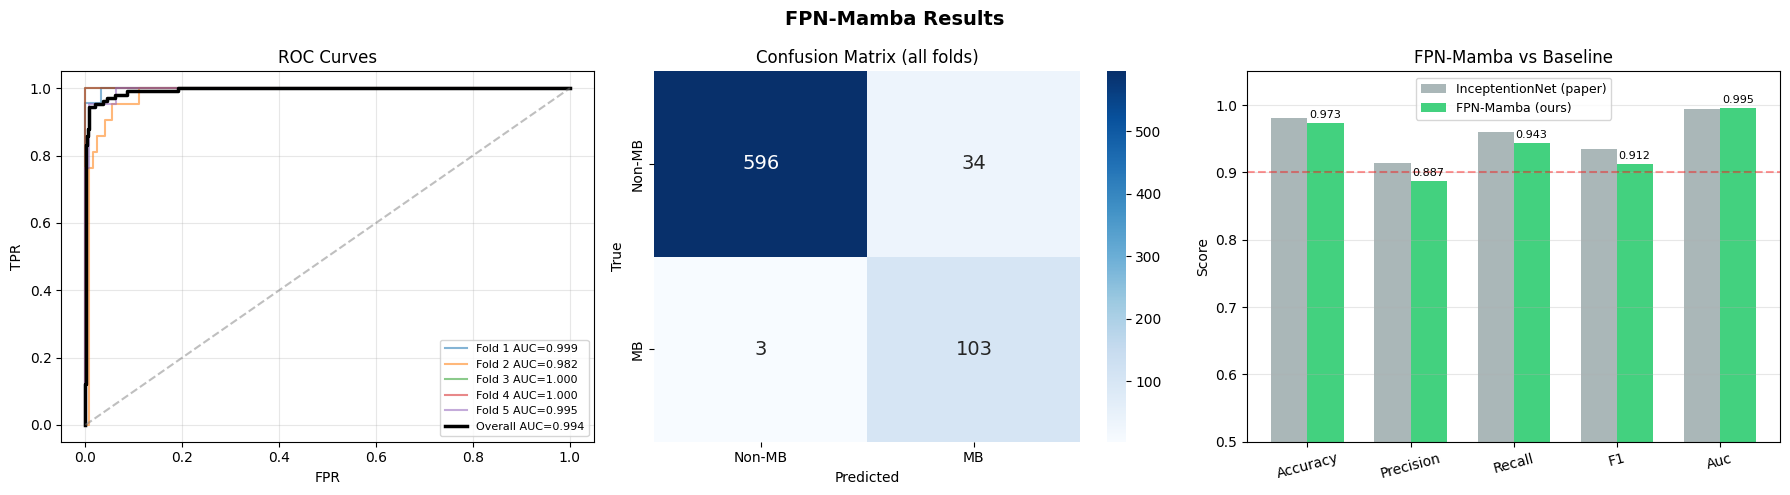

In [16]:
all_fl = np.concatenate(fold_labels)
all_fp = np.concatenate(fold_probs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FPN-Mamba Results', fontsize=14, fontweight='bold')

# ROC curves
ax = axes[0]
for i, (fl, fp) in enumerate(zip(fold_labels, fold_probs)):
    fpr, tpr, _ = roc_curve(fl, fp)
    ax.plot(fpr, tpr, alpha=0.55, label=f'Fold {i+1} AUC={roc_auc_score(fl,fp):.3f}')
fpr_m, tpr_m, _ = roc_curve(all_fl, all_fp)
ax.plot(fpr_m, tpr_m, 'k-', lw=2.5, label=f'Overall AUC={roc_auc_score(all_fl,all_fp):.3f}')
ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curves')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Confusion Matrix
ax = axes[1]
cm = confusion_matrix(all_fl, (all_fp > 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-MB','MB'], yticklabels=['Non-MB','MB'],
            annot_kws={'size': 14})
ax.set_title('Confusion Matrix (all folds)')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

# Metric bars vs baseline
ax  = axes[2]
x   = np.arange(len(metric_names)); w = 0.35
ax.bar(x-w/2, [paper[m] for m in metric_names], w,
       label='InceptentionNet (paper)', color='#95a5a6', alpha=0.8)
b2 = ax.bar(x+w/2, [our[m] for m in metric_names], w,
            label='FPN-Mamba (ours)', color='#2ecc71', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metric_names], rotation=15)
ax.set_ylim(0.5, 1.05); ax.set_title('FPN-Mamba vs Baseline')
ax.set_ylabel('Score'); ax.legend(fontsize=9)
ax.axhline(0.9, color='red', ls='--', alpha=0.4)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

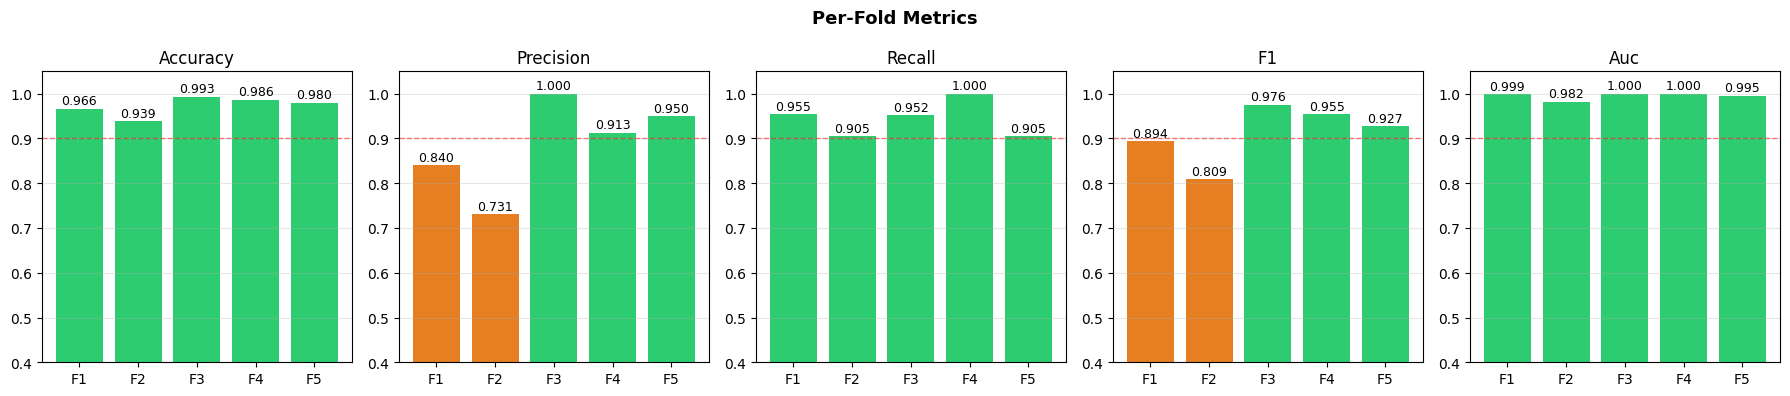

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Per-Fold Metrics', fontsize=13, fontweight='bold')
for ax, m in zip(axes, metric_names):
    vals   = [f[m] for f in fold_metrics]
    colors = ['#2ecc71' if v >= 0.9 else '#e67e22' for v in vals]
    bars   = ax.bar([f'F{i+1}' for i in range(N_FOLDS)], vals, color=colors)
    ax.axhline(0.9, color='red', ls='--', alpha=0.5, lw=1)
    ax.set_title(m.capitalize()); ax.set_ylim(0.4, 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
                f'{v:.3f}', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_fold.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Best Model & Inference

In [18]:
if best_state is not None:
    torch.save({
        'model_state_dict'    : best_state,
        'mean_metrics'        : our,
        'best_val_auc'        : best_val_auc,
        'backbone_out_indices': BACKBONE_OUT_INDICES,
        'config': dict(img_size=IMG_SIZE, backbone='efficientnet_b2',
                       fpn_channels=FPN_CH, dropout=DROPOUT, d_state=D_STATE)
    }, 'fpn_mamba_best.pt')
    print(f'Best model saved  (AUC={best_val_auc:.4f})')


def predict_single(image_path, model_path='fpn_mamba_best.pt', threshold=0.5):
    """Classify a single MRI image."""
    ckpt  = torch.load(model_path, map_location=DEVICE)
    model = FPNMambaClassifier().to(DEVICE)
    state = {k.replace('module.', ''): v for k, v in ckpt['model_state_dict'].items()}
    model.load_state_dict(state, strict=False)
    model.eval()
    x = val_transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logit = model(x).squeeze().item()
    prob = 1 / (1 + math.exp(-logit))
    return {'label': 'Medulloblastoma' if prob > threshold else 'Non-Medulloblastoma',
            'probability': round(prob, 4)}

# result = predict_single('path/to/scan.jpg')
# print(result)
print('predict_single() ready.')

Best model saved  (AUC=1.0000)
predict_single() ready.


## 11. Final Summary

In [19]:
print('='*70)
print('  FINAL SUMMARY')
print('='*70)
print('  Architecture : EfficientNet-B2 + FPN + Bidirectional Mamba')
print('  Key design   : Locality Mixing (Eq.9) + Naive Concat (Eq.7)')
print('  Transfer     : ImageNet pretrained, frozen early backbone layers')
print('  Training     : AdamW + CosineAnnealing + LabelSmoothing + EarlyStop')
print('  Evaluation   : 5-fold Stratified CV + WeightedRandomSampler')
print(f'  Dataset      : 106 MB + 630 Non-MB = 736 images (matches paper)')
print()
for m in metric_names:
    vals = [f[m] for f in fold_metrics]
    mu, sd = np.mean(vals), np.std(vals)
    mark = 'PASS' if mu >= 0.90 else 'WARN'
    print(f'  [{mark}] {m:<12}: {mu:.4f} +/- {sd:.4f}')

  FINAL SUMMARY
  Architecture : EfficientNet-B2 + FPN + Bidirectional Mamba
  Key design   : Locality Mixing (Eq.9) + Naive Concat (Eq.7)
  Transfer     : ImageNet pretrained, frozen early backbone layers
  Training     : AdamW + CosineAnnealing + LabelSmoothing + EarlyStop
  Evaluation   : 5-fold Stratified CV + WeightedRandomSampler
  Dataset      : 106 MB + 630 Non-MB = 736 images (matches paper)

  [PASS] accuracy    : 0.9728 +/- 0.0192
  [WARN] precision   : 0.8868 +/- 0.0938
  [PASS] recall      : 0.9433 +/- 0.0358
  [PASS] f1          : 0.9118 +/- 0.0585
  [PASS] auc         : 0.9953 +/- 0.0067


---
## References
1. Liang L., Wang C., Zhang L. — *MambaFPN: A SSM-based feature pyramid network for object detection*, Neural Networks 198 (2026) 108544
2. Fang C. et al. — *Precise identification of medulloblastoma in MRI images using a CNN integrated with self-attention*, Digital Health (2025)
3. Gu A., Dao T. — *Mamba: Linear-time sequence modeling with selective state spaces*, arXiv:2312.00752 (2023)
4. Zhu L. et al. — *Vision Mamba: Efficient visual representation learning with bidirectional state space model*, arXiv:2401.09417 (2024)
5. Lin T.Y. et al. — *Feature Pyramid Networks for Object Detection*, CVPR 2017